# Exploratory Data Analysis (EDA)

In [3]:
# DATASET URL: "https://drive.google.com/file/d/1NjvoUnUNAmVPSse1mhRSKQNbarsMThFA/view?usp=sharing"

In [1]:
import pandas as pd

In [4]:
# Load the training dataset
df = pd.read_json('train.jsonl', lines=True)

In [5]:
# View first 5 rows
df.head()

,id,verifiable,label,claim,evidence
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [92206, 104971, Fox_Broadcasting_Company, 0]]]"
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271, 187499, Roman_Atwood, 3]]]"
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, sculpture, music, painting, poetry literature, theatre, narrative, film, photography and graphic arts.","[[[255136, 254645, History_of_art, 2]]]"
3,156709,VERIFIABLE,REFUTES,Adrienne Bailon is an accountant.,"[[[180804, 193183, Adrienne_Bailon, 0]]]"
4,83235,NOT VERIFIABLE,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,"[[[100277, None, None, None]]]"


In [6]:
# check shape
df.shape

(145449, 5)

In [7]:
# check column names
df.columns

Index(['id', 'verifiable', 'label', 'claim', 'evidence'], dtype='object')

In [8]:
# check non null cols and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145449 entries, 0 to 145448
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          145449 non-null  int64 
 1   verifiable  145449 non-null  object
 2   label       145449 non-null  object
 3   claim       145449 non-null  object
 4   evidence    145449 non-null  object
dtypes: int64(1), object(4)
memory usage: 5.5+ MB


In [9]:
# check for null entries
df.isnull().sum()

id            0
verifiable    0
label         0
claim         0
evidence      0
dtype: int64

In [10]:
# Handle Missing Data
df = df.dropna(subset=['id', 'claim', 'label'])

In [11]:
# Check duplicates based on all columns except 'evidence', coz evidence is unhashable
duplicate_count = df.drop(columns=['evidence']).duplicated().sum()
print("Number of duplicate rows (ignoring evidence):", duplicate_count)

Number of duplicate rows (ignoring evidence): 0


In [12]:
# check frequency of each unique value in the label column.
df['label'].value_counts()

label
SUPPORTS           80035
NOT ENOUGH INFO    35639
REFUTES            29775
Name: count, dtype: int64

In [13]:
# check data with support labels
df[df['label']=='SUPPORTS'].head(3)

,id,verifiable,label,claim,evidence
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [92206, 104971, Fox_Broadcasting_Company, 0]]]"
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271, 187499, Roman_Atwood, 3]]]"
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, sculpture, music, painting, poetry literature, theatre, narrative, film, photography and graphic arts.","[[[255136, 254645, History_of_art, 2]]]"


In [14]:
# check data with refute labels
df[df['label']=='REFUTES'].head(3)

,id,verifiable,label,claim,evidence
3,156709,VERIFIABLE,REFUTES,Adrienne Bailon is an accountant.,"[[[180804, 193183, Adrienne_Bailon, 0]]]"
14,138503,VERIFIABLE,REFUTES,"Stranger Things is set in Bloomington, Indiana.","[[[161295, 175782, Stranger_Things, 5]]]"
16,73170,VERIFIABLE,REFUTES,Puerto Rico is not an unincorporated territory of the United States.,"[[[89957, 102650, Puerto_Rico, 0]]]"


In [15]:
# check data with not enough info labels
df[df['label']=='NOT ENOUGH INFO'].head(3)

,id,verifiable,label,claim,evidence
4,83235,NOT VERIFIABLE,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,"[[[100277, None, None, None]]]"
6,149579,NOT VERIFIABLE,NOT ENOUGH INFO,Beautiful reached number two on the Billboard Hot 100 in 2003.,"[[[173384, None, None, None]]]"
7,229289,NOT VERIFIABLE,NOT ENOUGH INFO,Neal Schon was named in 1954.,"[[[273626, None, None, None]]]"


In [16]:
# Average claim length, Shortest claim, Longest claim, etc
df['claim'].str.len().describe()

count    145449.000000
mean         47.634800
std          19.734687
min          10.000000
25%          35.000000
50%          44.000000
75%          57.000000
max         614.000000
Name: claim, dtype: float64

In [17]:
# Add a new column for claim length
df['claim_length'] = df['claim'].str.len()

# Shortest claim
shortest_idx = df['claim_length'].idxmin()
print(f"Shortest claim ({df.loc[shortest_idx, 'claim_length']} chars):\n{df.loc[shortest_idx, 'claim']}\n")

# Longest claim
longest_idx = df['claim_length'].idxmax()
print(f"Longest claim ({df.loc[longest_idx, 'claim_length']} chars):\n{df.loc[longest_idx, 'claim']}")


Shortest claim (10 chars):
Russ raps.

Longest claim (614 chars):
International Relations includes technology and engineering, economics, communication studies, history, international law, demography, philosophy, geography, social work, sociology, anthropology, criminology, psychology, gender studies, cultural studies, culturology, and diplomacy, globalization, diplomatic relations, state sovereignty, international security, ecological sustainability, nuclear proliferation, nationalism, economic development, global finance, as well as terrorism and organized crime, human security, foreign interventionism, and human rights, as well, as, more recently, comparative religion.


In [18]:
# Add a new column for claim word count
df['claim_word_count'] = df['claim'].apply(lambda x: len(x.split()))
df.head(3)

,id,verifiable,label,claim,evidence,claim_length,claim_word_count
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [92206, 104971, Fox_Broadcasting_Company, 0]]]",63,8
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271, 187499, Roman_Atwood, 3]]]",34,6
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, sculpture, music, painting, poetry literature, theatre, narrative, film, photography and graphic arts.","[[[255136, 254645, History_of_art, 2]]]",147,18


In [19]:
import matplotlib.pyplot as plt

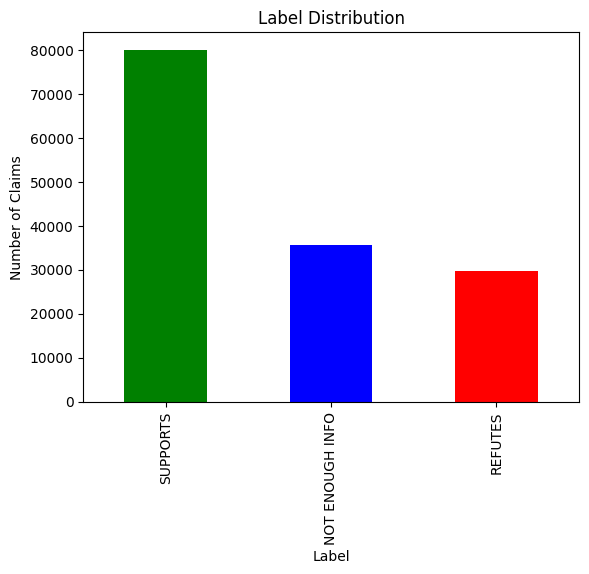

In [20]:
# check imbalance in the labels
df['label'].value_counts().plot(kind='bar', color=['green','blue','red'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Number of Claims')
plt.show()

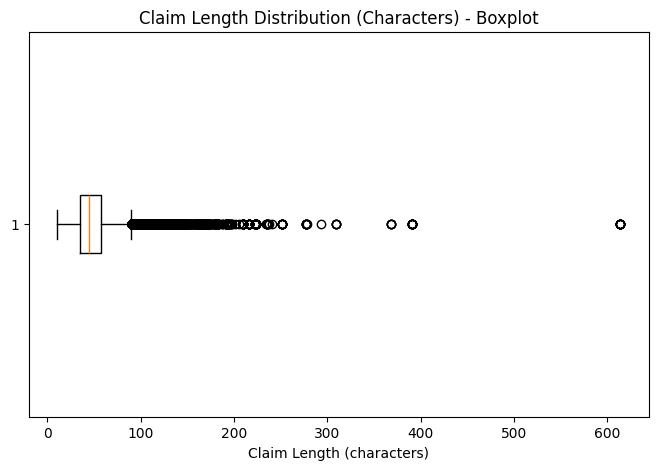

In [21]:
# check if the claims are unusually short or long

plt.figure(figsize=(8,5))
plt.boxplot(df['claim'].str.len(), vert=False)
plt.title('Claim Length Distribution (Characters) - Boxplot')
plt.xlabel('Claim Length (characters)')
plt.show()

In [22]:
# Add a new column for number of evidences per claim
df['evidence_count'] = df['evidence'].apply(lambda x: sum(len(group) for group in x if isinstance(group, list)))

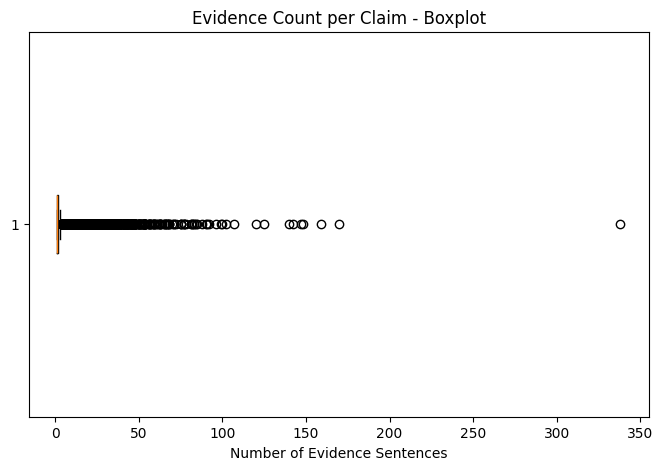

In [23]:
# check the distribution of number of evidence sentences per claim
plt.figure(figsize=(8,5))
plt.boxplot(df['evidence_count'], vert=False)
plt.title('Evidence Count per Claim - Boxplot')
plt.xlabel('Number of Evidence Sentences')
plt.show()


In [24]:
# check min, max and avg evidence count
print("Minimum evidence count:", df['evidence_count'].min())
print("Maximum evidence count:", df['evidence_count'].max())
print("Average evidence count:", df['evidence_count'].mean())

Minimum evidence count: 1
Maximum evidence count: 338
Average evidence count: 2.141169757096989


In [25]:
# check claim(s) with minimum evidence
print("Claim(s) with minimum evidence count:")
df[df['evidence_count'] == df['evidence_count'].min()][['id', 'claim', 'evidence_count']].head(3)

Claim(s) with minimum evidence count:


,id,claim,evidence_count
2,214861,"History of art includes architecture, dance, sculpture, music, painting, poetry literature, theatre, narrative, film, photography and graphic arts.",1
3,156709,Adrienne Bailon is an accountant.,1
4,83235,System of a Down briefly disbanded in limbo.,1


In [26]:
# check claim(s) with maximum evidence
print("Claim(s) with maximum evidence count:")
df[df['evidence_count'] == df['evidence_count'].max()][['id', 'claim', 'evidence_count']].head(3)

Claim(s) with maximum evidence count:


,id,claim,evidence_count
145043,1885,Leonardo DiCaprio is an actor.,338


In [27]:
# average number of char per claim for each label
df.groupby('label')['claim_length'].mean()

label
NOT ENOUGH INFO    47.864222
REFUTES            47.267238
SUPPORTS           47.669382
Name: claim_length, dtype: float64

In [28]:
# average number of words per claim for each label
df.groupby('label')['claim_word_count'].mean()

label
NOT ENOUGH INFO    8.062768
REFUTES            8.148346
SUPPORTS           8.101118
Name: claim_word_count, dtype: float64

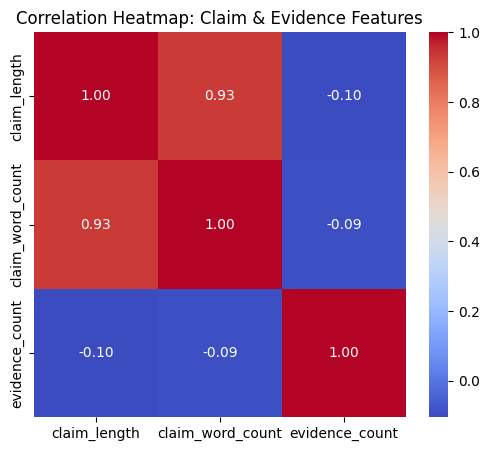

In [29]:
# Plot heatmap using numeric cols

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for correlation
cols = ['claim_length', 'claim_word_count', 'evidence_count']

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Claim & Evidence Features')
plt.show()

#### Notebook Setting: for showing all cols, rows and full text in each column

In [30]:
# pd.set_option('display.max_rows', None)       # show all rows
# pd.set_option('display.max_columns', None)    # show all columns
# pd.set_option('display.max_colwidth', None)   # show full text in each column

#### Notebook Setting: reset above settings

In [31]:
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')
# pd.reset_option('display.max_colwidth')
# pd.reset_option('all')